## Topics

## 1. Implementing the Sigmoid Activation Function
## 2. The "error" as the Loss Function
## 3. The "history" of w1 and w2.



## If you want to use interactive plots and are willing to take a risk do the following...

## Before we proceed, a STRONG word of caution: this could go wrong.  So if you don't want to take the risk, do NOT do the following.  The quick way around this: Launch jupyter notebook instead of jupyter lab, and use notebook as the backend for matplotlib and not inline:

        
        
```%matplotlib notebook```

## Proceed only if you want to have interactive figure in **jupyter lab** -- remember, if you get into trouble, you cannot count on me or the TA to bail you out!

### This is what worked for me.  But it has to be the right version of nodejs

        conda install -c conda-forge ipympl
        conda install -c conda-forge nodejs=10.13
        jupyter labextension install @jupyter-widgets/jupyterlab-manager
        jupyter lab build

### Then use the widget as the backend for matplotlib (instead of inline):

```%matplotlib widget```

### and for every figure, you need to do

```plt.figure()```

In [2]:
# All imports
from random import choice
import numpy as np
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'The Sigmoid Function')

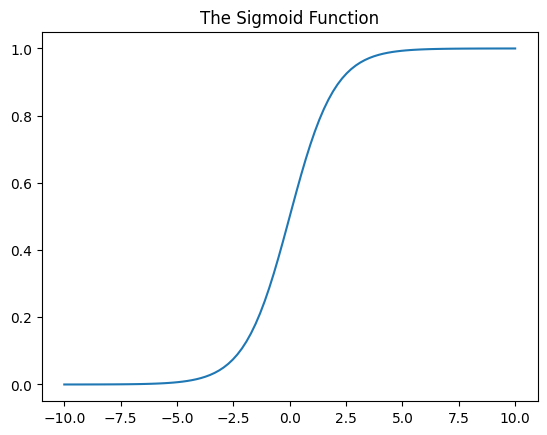

In [7]:
y = np.linspace(-10,10,100)
z = 1/(1+np.exp(-y))

plt.plot(y,z)
plt.title('The Sigmoid Function')

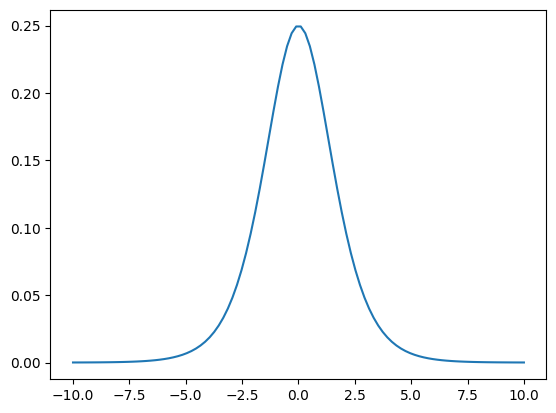

In [8]:
def sigmoid_deriv(z):
    return z*(1-z)

z_pr = sigmoid_deriv(z)

plt.plot(y,z_pr)

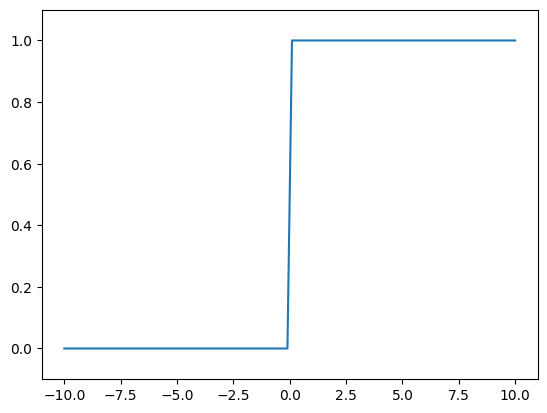

In [3]:
"Step Function"

step_fun = lambda x: x > 0 
# x = np.array([-1, 1])
# step_fun(x)
x = np.linspace(-10, 10, 100)
z = step_fun(x)
plt.figure()
plt.plot(x, z)
plt.ylim(-.1, 1.1)
plt.show()

## Let's turn this into a classifier!!

In [26]:
'''

Perceptron to implement the NOR operation

This version ensures training is only done once, achieving perfect boundary and of course faster speed


'''
def training(training_data, show_train = False):
    # usu. random numbers for weights is not a bad starting point
    w = np.random.rand(3)
    errors = []

    # "learning rate"
    alfa = 0.2

    # use 100 training steps
    n = 100
    # w.history = []
    for i in range(n):
        x_train, target = choice(training_data)
        y = np.dot(w, x_train)
        error = target - step_fun(y)
        errors.append(error)
        w += alfa * error * x_train

    if show_train:
        print('weights:', w)
        print('Training results:')
        for x_train, _ in training_data:
            y = np.dot(x_train, w)
            print("{}: {} -> {}".format(x_train[:2], y, step_fun(y)))

    return w

def NOR_perceptron_classifier(x, w_trained=[], show_train=False):    
    training_data = [
        (np.array([0,0,1]), 1),
        (np.array([0,1,1]), 0),
        (np.array([1,0,1]), 0),
        (np.array([1,1,1]), 0),
    ]

    if len(w_trained) == 0:
        w_trained = training(training_data, show_train = show_train)
    
    x = np.append(x, 1)
    return step_fun(np.dot(x, w_trained)), w_trained

x_arr = np.random.rand(1000, 2)

z_arr = np.array([])
for i, x in enumerate(x_arr):
    if i == 0:
        z, w_trained = NOR_perceptron_classifier(x)
    else:
        z, _ = NOR_perceptron_classifier(x, w_trained = w_trained)
    z_arr = np.append(z_arr, z)



for i, x in enumerate(x_arr):
    if z_arr[i]:
        plt.plot(x[0], x[1], 'r.')
    else:
        plt.plot(x[0], x[1], 'b.')

x0 = np.array([0, 1])

x1 = x0 * (-w_trained[0] / w_trained[1]) - w_trained[2] / w_trained[1]
plt.figure()
plt.plot(x0, x1, 'g-')
plt.axis([-0.1, 1.1, -0.1, 1.1])
x_train = [np.array([0, 0, 1, 1]), np.array([0,1,0,1])]
plt.plot([0, 1, 1], [1, 0, 1], 'bo', ms = 10)
plt.plot([0,], [0,], 'ro', ms = 10);



Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [27]:
'''
Sigmoid function
'''
plt.figure()
y = np.linspace(-10, 10, 100)
S = 1 / (1 + np.e ** (-y))
plt.plot(y, S)
plt.title('The Sigmoid (Logistic) Function')
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

## Breakout Exercise:

## Re-implement the perceptron classifier using the sigmoid function, instead of the step function

## Preliminary Steps:

### 1. Write a sigmoid function
### 2. Write a function that calculates the derivative of the sigmoid function (remember it's easier to express it in terms of z, the output -- see lab exercise for Week 5-1 for the tahn function)

### 3. Rewrite the classifier function so that it uses the sigmoid rather than the step function as the activation


## In addition:

## 4. Rewrite the classifier function, such that it has the following call signature

     perceptron_classifier(x, N=1000, alfa=0.2, show_train=False, w_trained=[], training_data=[])
 
   ### Obviously, it's NOT OK to have both ```w_trained``` and ```training_data``` as empty list.  You need to "handle" that situation in your function defintion.
   
## 5. After the training is done, plot error and error^2 vs. training steps.


In [28]:
'''
Re-implement perceptron classifier solution:

sigmoid function and its derivative

'''

def sigmoid(x):
    '''The logistic function as the activation'''
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_prime(z):
    '''derivative of the logistic function'''
    return z * (1.0 - z)

In [29]:
'''
Re-implement perceptron classifier solution:

with sigmoid as activation function, and a new call sigature

'''

def perceptron_classifier(x, N=1000, alfa=0.2, show_train=False, w_trained=[], training_data=[]):    
    '''
    A general Perceptron with sigmoid as the activation function

    Takes in training and testing data.

    '''
    if len(w_trained) == 0 and len(training_data) == 0:
        print('w_trained and trainsing_data cannot both be empty.')
        return

    errors = []
    w_history = np.array([])
    if len(w_trained) == 0:
        w = np.random.rand(3)
        print('Starting with random weights, w = {}'.format(w))
        w_history = np.append(w_history, w)
        # if you want, you can also see w "evolves" over the training stage
        for i in range(N):
            
            x_train, target = choice(training_data)
            y = np.dot(w, x_train)
            z = sigmoid(y)
            error = target - z
            errors.append(error)
            dP_dw = error * x_train * sigmoid_prime(z)
            w += alfa * dP_dw
            w_history = np.append(w_history, w)
            
        if show_train:
            print('weights:', w)
            print('Training results:')
            for x_train, _ in training_data:
                y = np.dot(x_train, w)
                print("{}: {:.4f} -> {}".format(x_train[:2], y, sigmoid(y)))
                
    else:
        w = w_trained
        
    x = np.append(x, 1)
    return sigmoid(np.dot(x, w)), w, np.array(errors), w_history

# NOR
# training_data = [
#     (np.array([0,0,1]), 1),
#     (np.array([0,1,1]), 0),
#     (np.array([1,0,1]), 0),
#     (np.array([1,1,1]), 0),
# ]

# OR
# training_data = [
#     (np.array([0,0,1]), 0),
#     (np.array([0,1,1]), 1),
#     (np.array([1,0,1]), 1),
#     (np.array([1,1,1]), 1),
# ]



# AND
training_data = [
    (np.array([0,0,1]), 0),
    (np.array([0,1,1]), 0),
    (np.array([1,0,1]), 0),
    (np.array([1,1,1]), 1),
]

# XOR
# training_data = [
#     (np.array([0,0,1]), 0),
#     (np.array([0,1,1]), 1),
#     (np.array([1,0,1]), 1),
#     (np.array([1,1,1]), 0),
# ]


#----------------------------------------------
# Now try varying alfa (say bewteen 0.2 and 20!), and N.
#----------------------------------------------
train_steps = 200
alfa = 4
x_arr = np.random.rand(1000, 2)

z_arr = np.array([])
for i, x in enumerate(x_arr):
    if i == 0:
        z, w_trained, errors, w_history = perceptron_classifier(x, alfa=alfa, N=train_steps, training_data=training_data)
        print('trained weights, w = {}'.format(w_trained))
        print('w_history shape', w_history.shape)
    else:
        z = perceptron_classifier(x, w_trained=w_trained)[0]
    z_arr = np.append(z_arr, z)


    
threshold = 0.5
plt.figure()
for i, x in enumerate(x_arr):
    # Here the threshold is set at 0.5 (before, using the step function, it was set at 1)
    if z_arr[i] > threshold:
        plt.plot(x[0], x[1], 'r.')
    else:
        plt.plot(x[0], x[1], 'b.')

# AND training set
plt.plot([0, 1, 0], [1, 0, 0], 'bo', ms=10) #, label='Trainning Data (Negative)')
plt.plot([1,], [1,], 'ro', ms=10) #, label='Trainning Data (Positive)')
# plt.legend()
plt.show()


Starting with random weights, w = [0.45421409 0.15919867 0.531717  ]
trained weights, w = [ 3.38588693  3.9193229  -5.52711182]
w_history shape (603,)


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [37]:
w_history = w_history.reshape(train_steps+1, -1)
print(w_history[0], w_history[-1])
print(w_history.shape)

w1_history, w2_history = w_history.T[0], w_history.T[1]

[0.45421409 0.15919867 0.531717  ] [ 3.38588693  3.9193229  -5.52711182]
(201, 3)


In [31]:
'''
Re-implement perceptron classifier solution:

error and error^2 as a function of training steps
'''
plt.figure()
plt.plot(range(train_steps), errors)
plt.plot(range(train_steps), errors, 'r.')
plt.plot(np.zeros(len(errors)), '--')
plt.ylabel('Error')
plt.xlabel('Training Steps')

plt.figure()
plt.plot(errors**2)
plt.plot(errors**2, 'r.')
plt.ylabel('Error squared ("loss")')
plt.xlabel('Training Steps')
# plt.ylim(-1e-3, 1e-2 )
plt.show()



Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [32]:
loss = errors ** 2

loss_smooth = np.convolve(loss, np.ones((32,))/32, mode='same')

plt.figure()
plt.plot(loss_smooth)
plt.plot(loss_smooth, 'r.')
plt.ylabel('Error squared ("loss")')
plt.xlabel('Training Steps')
# plt.ylim(-1e-3, 1e-2 )
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

## Compare this error vs. training step vs. the "binary" one when we used the step function

## Note the error^2 *is* the loss function, it is the negative of the performance function:

## $P = -\frac{1}{2} (d - z)^2$

## $\mathrm{Loss} = \frac{1}{2} (d - z)^2$

## From now on we will use the loss function.

## Also Change in notation:

## $d \rightarrow y$



In [40]:
'''
Note: technically, the weight for the bias should also be shown as it was being trained as well.  
But can't show 4D plot easily!

Possible improvement: 

1. Make the points update as training proceeds (see beginning of Week8-1 for dynamic plotting)
2. Predict the theoretical shape of P(w0, w1, w2)?  And then project onto P(w1, w2).

'''

# This import registers the 3D projection, but is otherwise unused.
from mpl_toolkits.mplot3d import Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n = 100

ax.scatter(w1_history[:-1], w2_history[:-1], loss_smooth, marker='o')
ax.plot3D(w1_history[:-1], w2_history[:-1], loss_smooth, 'gray')
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('Loss')

plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [66]:
print(w_history[:-1].T[0].shape, w_history[:-1].T[1].shape)

() ()
